# Usage of PySpark SQL

# Last Class Stuff

In [ ]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
                     .appName("Analyzing an unknown article.")
                     .getOrCreate())


In [ ]:
## documentation
spark.read??

In [ ]:
file_path = r'white_house_news.txt'

In [ ]:
article = spark.read.text(file_path)

In [ ]:
article.show(5, truncate=False)

+-----------------------------------------------------------------------------------+
|value                                                                              |
+-----------------------------------------------------------------------------------+
|Here's a look inside security at the White House Correspondents' Association Dinner|
|By Tamara Keith                                                                    |
|Updated Monday, April 27, 2026 • 3:30 PM EDT                                       |
|                                                                                   |
|Tamara Keith was president of the WHCA from 2022-2023 and planned the 2023 dinner. |
+-----------------------------------------------------------------------------------+
only showing top 5 rows


In [ ]:
from pyspark.sql.functions import col

In [ ]:

article.select(article.value)
article.select(article['value'])
article.select(col('value'))
article.select('value')

DataFrame[value: string]

In [ ]:
from pyspark.sql.functions import col, split
lines = article.select(split(col('value'), ' ').alias('line'))
lines.show(5, truncate=False)


+--------------------------------------------------------------------------------------------------+
|line                                                                                              |
+--------------------------------------------------------------------------------------------------+
|[Here's, a, look, inside, security, at, the, White, House, Correspondents', Association, Dinner]  |
|[By, Tamara, Keith]                                                                               |
|[Updated, Monday,, April, 27,, 2026, •, 3:30, PM, EDT]                                            |
|[]                                                                                                |
|[Tamara, Keith, was, president, of, the, WHCA, from, 2022-2023, and, planned, the, 2023, dinner. ]|
+--------------------------------------------------------------------------------------------------+
only showing top 5 rows


In [ ]:
from pyspark.sql.functions import explode
words = lines.select(explode(col('line')).alias('word'))
words.show(5, truncate=False)


+--------+
|word    |
+--------+
|Here's  |
|a       |
|look    |
|inside  |
|security|
+--------+
only showing top 5 rows


In [ ]:
from pyspark.sql.functions import lower


In [ ]:
from pyspark.sql.functions import regexp_extract



# In Class Activity

**Filtering Words**

In [ ]:


from pyspark.sql.functions import length

word_clean = words.select(
    lower(regexp_extract(col('word'), r'[a-zA-Z]+', 0)).alias('word')
)

word_clean = word_clean.where(col('word') != '')
word_clean = word_clean.where(length(col('word')) > 3)

word_clean.show()

+--------------+
|          word|
+--------------+
|          here|
|          look|
|        inside|
|      security|
|         white|
|         house|
|correspondents|
|   association|
|        dinner|
|        tamara|
|         keith|
|       updated|
|        monday|
|         april|
|        tamara|
|         keith|
|     president|
|          whca|
|          from|
|       planned|
+--------------+
only showing top 20 rows


**Top 5**

In [ ]:
top5 = (
    word_clean
    .groupBy('word')
    .count()
    .orderBy(col('count').desc())
    .limit(5)
)

top5.show()

+---------+-----+
|     word|count|
+---------+-----+
|president|   29|
|     that|   25|
| security|   19|
|     this|   19|
|     with|   16|
+---------+-----+



**Table of Word Length and Frequencies**

In [ ]:
all_words = (
    article
    .select(explode(split(col("value"), r"\s+")).alias("word"))
    .select(lower(regexp_extract(col("word"), r"[a-zA-Z]+", 0)).alias("word"))
    .where(col("word") != "")
)

length_table = ( all_words
    .withColumn("word_length", length(col("word")))
    .groupBy("word_length")
    .count()
    .orderBy("word_length")
)

length_table.show()

+-----------+-----+
|word_length|count|
+-----------+-----+
|          1|   52|
|          2|  192|
|          3|  290|
|          4|  274|
|          5|  166|
|          6|  130|
|          7|   98|
|          8|   79|
|          9|   74|
|         10|   19|
|         11|   12|
|         12|    7|
|         13|    4|
|         14|    5|
|         15|    1|
+-----------+-----+



**Histogram of occurences of each alphabet leter ordered from highest to lowest usage**

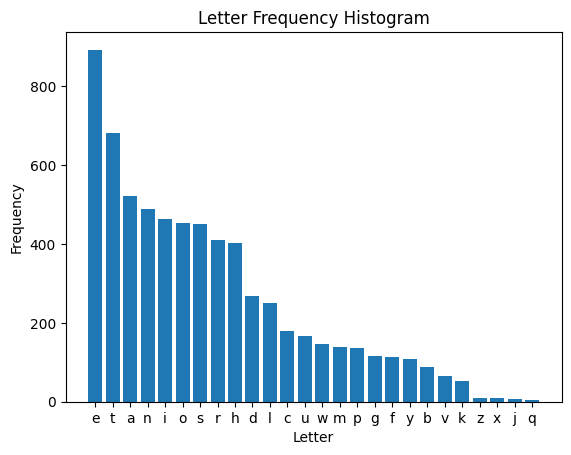

In [36]:
import matplotlib.pyplot as plt


letters = article.select(
    explode(split(lower(col("value")), "")).alias("letter")
)

letters = letters.where(col("letter").rlike("[a-z]"))

letter_counts = letters.groupBy("letter").count()
letter_counts = letter_counts.orderBy(col("count").desc())

letter_pd = letter_counts.toPandas()

plt.bar(letter_pd["letter"], letter_pd["count"])
plt.xlabel("Letter")
plt.ylabel("Frequency")
plt.title("Letter Frequency Histogram")
plt.show()